# Phase 5: Model Evaluation and Explainable AI (XAI)
In this phase, we ensure our production model is robust using **Cross-Validation** and explain its decisions using **SHAP (SHapley Additive exPlanations)**.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.model_selection import cross_val_score
import shap

# Set visual style
sns.set_theme(style="whitegrid")
shap.initjs() # Required for some interactive SHAP plots

# 1. Load the Raw Data
df = pd.read_csv('../data/raw/StudentsPerformance.csv', sep=',') # Use appropriate separator
X = df.drop('math score', axis=1)
y = df['math score']

# 2. Load the Local Production Model
pipeline = joblib.load('../models/student_math_model.pkl')
print("Data and Local Model Pipeline loaded successfully!")

Data and Local Model Pipeline loaded successfully!


## 1. Bias-Variance Tradeoff Check (Cross-Validation)
A single train/test split can be lucky or unlucky. To prove our model is truly stable and not overfitting, we perform a **5-Fold Cross-Validation**. This trains and tests the model on 5 different slices of the data.

Cross-Validation R2 Scores: [0.86782736 0.86008612 0.81987599 0.86711991 0.87256209]
Average R2 Score: 0.8575
Standard Deviation: 0.0192


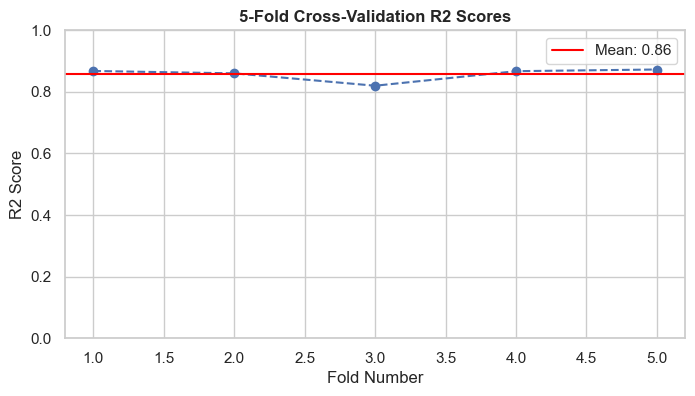

In [11]:
# Perform 5-Fold Cross Validation for R2 Score
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

print(f"Cross-Validation R2 Scores: {cv_scores}")
print(f"Average R2 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

# Plotting the CV results
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='--', color='b')
plt.title('5-Fold Cross-Validation R2 Scores', fontweight='bold')
plt.xlabel('Fold Number')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.axhline(cv_scores.mean(), color='red', linestyle='-', label=f'Mean: {cv_scores.mean():.2f}')
plt.legend()
plt.show()

# Insight: If the Standard Deviation is low (e.g., < 0.05), your model is highly stable!

## 2. SHAP (SHapley Additive exPlanations) Setup
SHAP uses cooperative game theory to explain the output of any ML model. Since our model is wrapped in a `scikit-learn` Pipeline, we need to extract the transformed features and the regressor separately to run SHAP.

In [13]:
# Step A: Get the preprocessor and the actual Gradient Boosting model from the pipeline
preprocessor = pipeline.named_steps['preprocessor']
model = pipeline.named_steps['regressor']

# Step B: Transform the raw data into scaled/encoded data
X_transformed = preprocessor.transform(X)

# Step C: Get the new column names (since OneHotEncoder creates new columns like 'gender_male')
# This is a dynamic way to get feature names after transformation
cat_encoder = preprocessor.named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(X.select_dtypes(include=['object']).columns)
num_features = X.select_dtypes(exclude=['object']).columns

# Combine numerical and categorical feature names
all_feature_names = np.concatenate([num_features, cat_features])

# Create a DataFrame of the transformed data for SHAP
X_transformed_df = pd.DataFrame(X_transformed, columns=all_feature_names)

print("Data successfully transformed for SHAP analysis!")

Data successfully transformed for SHAP analysis!


## 3. Global Interpretability: What drives Math Scores overall?
The SHAP Summary Plot shows the most important features and whether a high/low value of that feature positively or negatively impacts the math score.

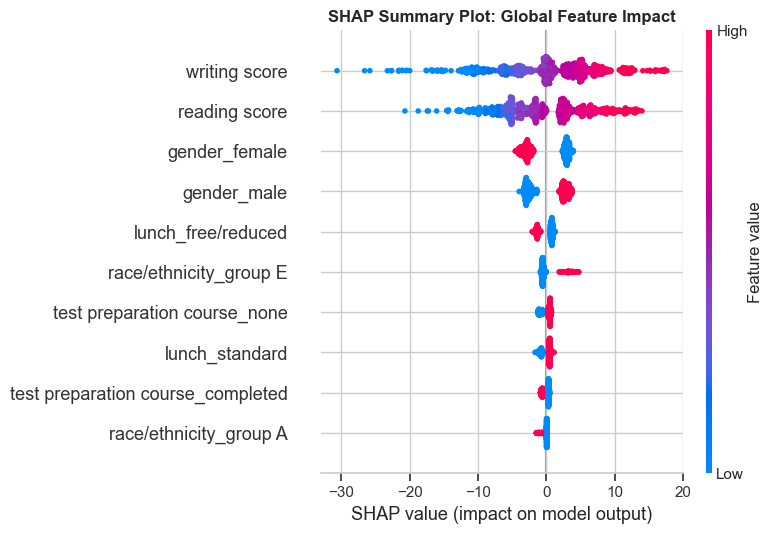

In [14]:
# Initialize the SHAP TreeExplainer (optimized for Gradient Boosting / Random Forest)
explainer = shap.Explainer(model)
shap_values = explainer(X_transformed_df)

# Global Summary Plot
plt.title("SHAP Summary Plot: Global Feature Impact", fontweight='bold')
shap.summary_plot(shap_values, X_transformed_df, max_display=10)

# How to read this for your report:
# - Red points mean the feature value is HIGH. Blue means LOW.
# - If red points are on the right side of the center line, a HIGH value INCREASES the math score.

## 4. Local Interpretability: Explaining a Single Student
Let's take **Student 0** and explain exactly why the model predicted their specific math score. This is exactly what you would show to a teacher or parent.

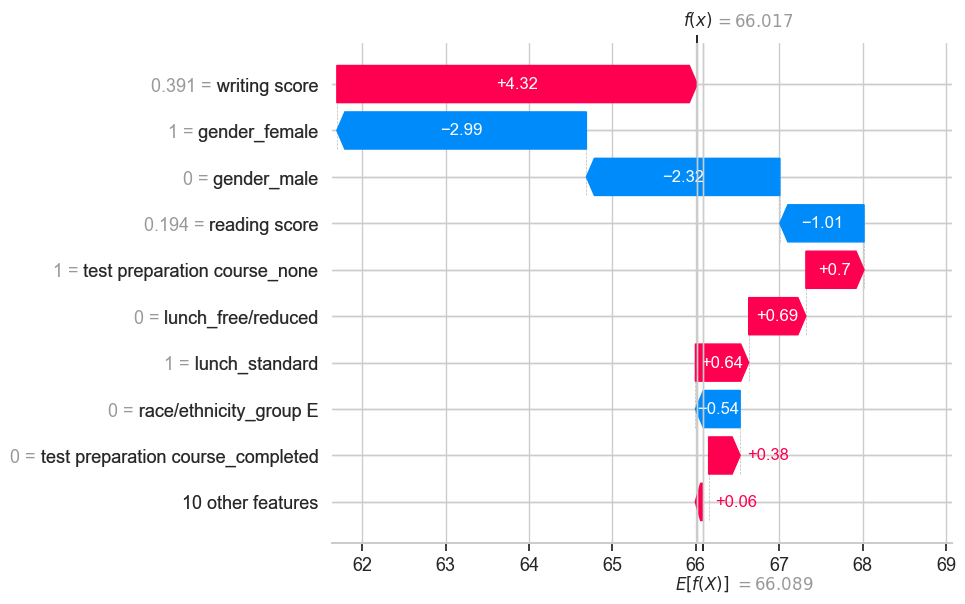

--- Student 0 Explanation ---
The Base Value (E[f(x)]) is the average math score of all students.
The red/blue bars show exactly how many points this specific student gained or lost based on their unique characteristics!


In [15]:
# Let's predict for the very first student in the dataset (Index 0)
student_idx = 0

# Generate a Waterfall plot
shap.plots.waterfall(shap_values[student_idx], max_display=10)

print(f"--- Student {student_idx} Explanation ---")
print("The Base Value (E[f(x)]) is the average math score of all students.")
print("The red/blue bars show exactly how many points this specific student gained or lost based on their unique characteristics!")